In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Data preprocessing

In [4]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred", ##subdirectory
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32, ##divide images into parts
    image_size=(128, 128),
    shuffle=True,  ## picks folders of images randomly otherwise linewise
    seed=None,## it helps in internal shuffling
    validation_split=None, ##if validate data is not separate then the value is b/w 0-1
    subset=None, 
    interpolation="bilinear", ##images comes in smoothly or it gives smoothness to images
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None, ## u can editting the image using keras 
    # verbose=True, 
)

Found 70295 files belonging to 38 classes.


## Validation Image Processing

In [5]:
validate_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred", ##subdirectory
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32, ##divide images into parts
    image_size=(128, 128),
    shuffle=True,  ## picks folders of images randomly otherwise linewise
    seed=None,## it helps in internal shuffling
    validation_split=None, ##if validate data is not separate then the value is b/w 0-1
    subset=None, 
    interpolation="bilinear", ##images comes in smoothly or it gives smoothness to images
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None, ## u can editting the image using keras 
    # verbose=True, 
)

Found 17572 files belonging to 38 classes.


In [6]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[121.   133.   133.  ]
   [120.5  132.5  132.5 ]
   [124.5  136.5  136.5 ]
   ...
   [148.5  157.5  156.5 ]
   [150.25 159.25 158.25]
   [151.   160.   159.  ]]

  [[121.   133.   133.  ]
   [120.5  132.5  132.5 ]
   [124.5  136.5  136.5 ]
   ...
   [155.5  164.5  163.5 ]
   [158.25 167.25 166.25]
   [155.25 164.25 163.25]]

  [[121.   133.   133.  ]
   [120.5  132.5  132.5 ]
   [124.5  136.5  136.5 ]
   ...
   [156.75 165.75 164.75]
   [156.   165.   164.  ]
   [149.25 158.25 157.25]]

  ...

  [[ 43.    53.    54.  ]
   [ 43.    53.    54.  ]
   [ 44.5   54.5   55.5 ]
   ...
   [ 82.25  92.25  91.25]
   [ 81.    91.    90.  ]
   [ 78.    88.    87.  ]]

  [[ 44.    54.    55.  ]
   [ 44.    54.    55.  ]
   [ 42.5   52.5   53.5 ]
   ...
   [ 82.25  92.25  91.25]
   [ 88.25  98.25  97.25]
   [ 86.5   96.5   95.5 ]]

  [[ 42.    52.    53.  ]
   [ 43.5   53.5   54.5 ]
   [ 42.25  52.25  53.25]
   ...
   [ 81.    91.    90.  ]
   [ 82.25  92.25  91.25]
   [ 79.    89.    8

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D
from tensorflow.keras.layers import Flatten ,MaxPool2D


In [9]:
model=Sequential()

In [10]:
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2)) ##shift

In [11]:
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [15]:
model.add(Flatten())

In [16]:
model.add(Dense(units=1500,activation='relu')) ###1024-> neural networks...input layer

In [17]:
model.add(Dense(units=38,activation='softmax')) ##output layer ->38

In [18]:
pip install tf_keras

Note: you may need to restart the kernel to use updated packages.


In [19]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy']) ###optimizer->algos,loss->

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
training_history=model.fit(training_set,validation_data=validate_set,epochs=10)q

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2104s 956ms/step - accuracy: 0.5009 - loss: 1.7365 - val_accuracy: 0.8578 - val_loss: 0.4523
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 8349s 4s/step - accuracy: 0.8772 - loss: 0.3788 - val_accuracy: 0.9046 - val_loss: 0.2934
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 8340s 4s/step - accuracy: 0.9302 - loss: 0.2105 - val_accuracy: 0.9243 - val_loss: 0.2354
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 38965s 18s/step - accuracy: 0.9518 - loss: 0.1434 - val_accuracy: 0.9253 - val_loss: 0.2529
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1906s 868ms/step - accuracy: 0.9641 - loss: 0.1099 - val_accuracy: 0.9427 - val_loss: 0.1829
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1858s 846ms/step - accuracy: 0.9726 - loss: 0.0802 - val_accuracy: 0.9426 - val_loss: 0.1921
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1914s 871ms/step - accuracy: 0.9772 - loss: 0.0704 - val_accuracy: 0.9295 - val_loss: 0.2399
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3390s 2s/step - accu

## Model Evaluation

In [22]:
train_set,train_acc=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 447s 203ms/step - accuracy: 0.9928 - loss: 0.0229


In [23]:
print(train_set,train_acc)

0.0178684052079916 0.9942528009414673


In [24]:
val_set,val_acc=model.evaluate(validate_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 112s 203ms/step - accuracy: 0.9615 - loss: 0.1412


In [25]:
print(val_set,val_acc)

0.1367419958114624 0.9631231427192688


## Saving Model

In [26]:
model.save("trained_model.keras")

In [28]:
training_history.history

{'accuracy': [0.6872323751449585,
  0.8934205770492554,
  0.9359413981437683,
  0.9566683173179626,
  0.9665552377700806,
  0.9737534523010254,
  0.9788604974746704,
  0.981961727142334,
  0.9836688041687012,
  0.9866846799850464],
 'loss': [1.038239598274231,
  0.3268224596977234,
  0.19218648970127106,
  0.12886445224285126,
  0.10030101984739304,
  0.07822397351264954,
  0.0648750588297844,
  0.055018071085214615,
  0.051189638674259186,
  0.040593236684799194],
 'val_accuracy': [0.8578420281410217,
  0.9046210050582886,
  0.9242544770240784,
  0.9253357648849487,
  0.9426929354667664,
  0.9425790905952454,
  0.9294900894165039,
  0.9516844749450684,
  0.9475301504135132,
  0.9631231427192688],
 'val_loss': [0.45225971937179565,
  0.2933923006057739,
  0.23539988696575165,
  0.25293588638305664,
  0.18285194039344788,
  0.192085862159729,
  0.23991328477859497,
  0.17697221040725708,
  0.18503770232200623,
  0.13674196600914001]}

## Recording history in Json

In [29]:
import json
with open("training_set.json","w") as f:
    json.dump(training_history.history,f)

In [30]:
training_history.history["accuracy"]

[0.6872323751449585,
 0.8934205770492554,
 0.9359413981437683,
 0.9566683173179626,
 0.9665552377700806,
 0.9737534523010254,
 0.9788604974746704,
 0.981961727142334,
 0.9836688041687012,
 0.9866846799850464]

In [ ]:
training_history.history["val_accuracy"]

## Accuracy Visualisation

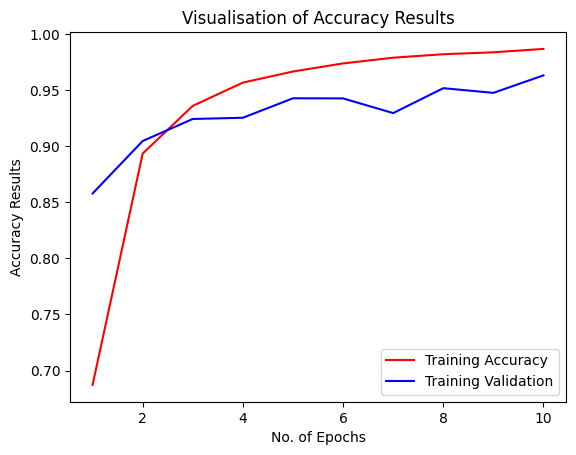

In [33]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Training Validation')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Results")
plt.title("Visualisation of Accuracy Results")
plt.legend()
plt.show()

## Some Other Metrics For Model Evaluation

In [34]:
class_name=validate_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [36]:
test_set =  tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [157]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 97s 175ms/step


(array([[1.00000000e+00, 7.28738181e-09, 3.19399699e-13, ...,
         1.95040930e-19, 8.43163645e-18, 2.39916160e-13],
        [9.99999881e-01, 6.35452082e-08, 1.35643721e-14, ...,
         1.19843791e-15, 4.64840988e-16, 9.55837785e-14],
        [1.00000000e+00, 2.89207658e-09, 4.00287008e-13, ...,
         8.50939538e-22, 1.07915174e-16, 8.72870949e-13],
        ...,
        [1.74274258e-11, 2.78768474e-15, 3.15808686e-13, ...,
         1.31402918e-11, 1.16764373e-14, 1.00000000e+00],
        [1.19453230e-08, 5.07693367e-12, 1.69418382e-10, ...,
         1.56798343e-08, 3.12080188e-11, 9.99999642e-01],
        [1.89598974e-13, 3.98725063e-16, 3.75609190e-16, ...,
         4.21082842e-17, 2.12888891e-11, 1.00000000e+00]], dtype=float32),
 (17572, 38))

In [191]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [192]:
true_categories = tf.concat([y for x,y in test_set] , axis=0)
true_categories

<tf.Tensor: shape=(17572,), dtype=int32, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32)>

In [193]:
# y_true = tf.argmax(true_categories,axis=1)
# y_true = y_true.numpy() 
# y_true


In [194]:
y_true=true_categories.numpy()  
y_true

array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32)

In [195]:
# import numpy as np
# Y_true= np.int64(17091)


In [196]:
# import numpy as np
# y_true =  np.int64(17091) 

In [197]:
from sklearn.metrics import classification_report,confusion_matrix

In [198]:
classification_report(y_true,predicted_categories,target_names=class_name)

'                                                    precision    recall  f1-score   support\n\n                                Apple___Apple_scab       0.95      0.96      0.95       504\n                                 Apple___Black_rot       0.95      0.99      0.97       497\n                          Apple___Cedar_apple_rust       0.99      0.93      0.96       440\n                                   Apple___healthy       0.96      0.97      0.97       502\n                               Blueberry___healthy       0.98      0.96      0.97       454\n          Cherry_(including_sour)___Powdery_mildew       0.97      0.98      0.98       421\n                 Cherry_(including_sour)___healthy       0.98      0.99      0.98       456\nCorn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.90      0.92       410\n                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477\n               Corn_(maize)___Northern_Leaf_Blight       0.95      

In [200]:
cm = confusion_matrix(y_true,predicted_categories)
cm

array([[483,   7,   0, ...,   0,   0,   0],
       [  0, 492,   0, ...,   0,   0,   0],
       [  1,   0, 411, ...,   2,   1,   1],
       ...,
       [  0,   0,   0, ..., 486,   0,   0],
       [  0,   0,   0, ...,   0, 448,   0],
       [  0,   0,   1, ...,   0,   0, 464]])

## Confusion metrix Visualisation

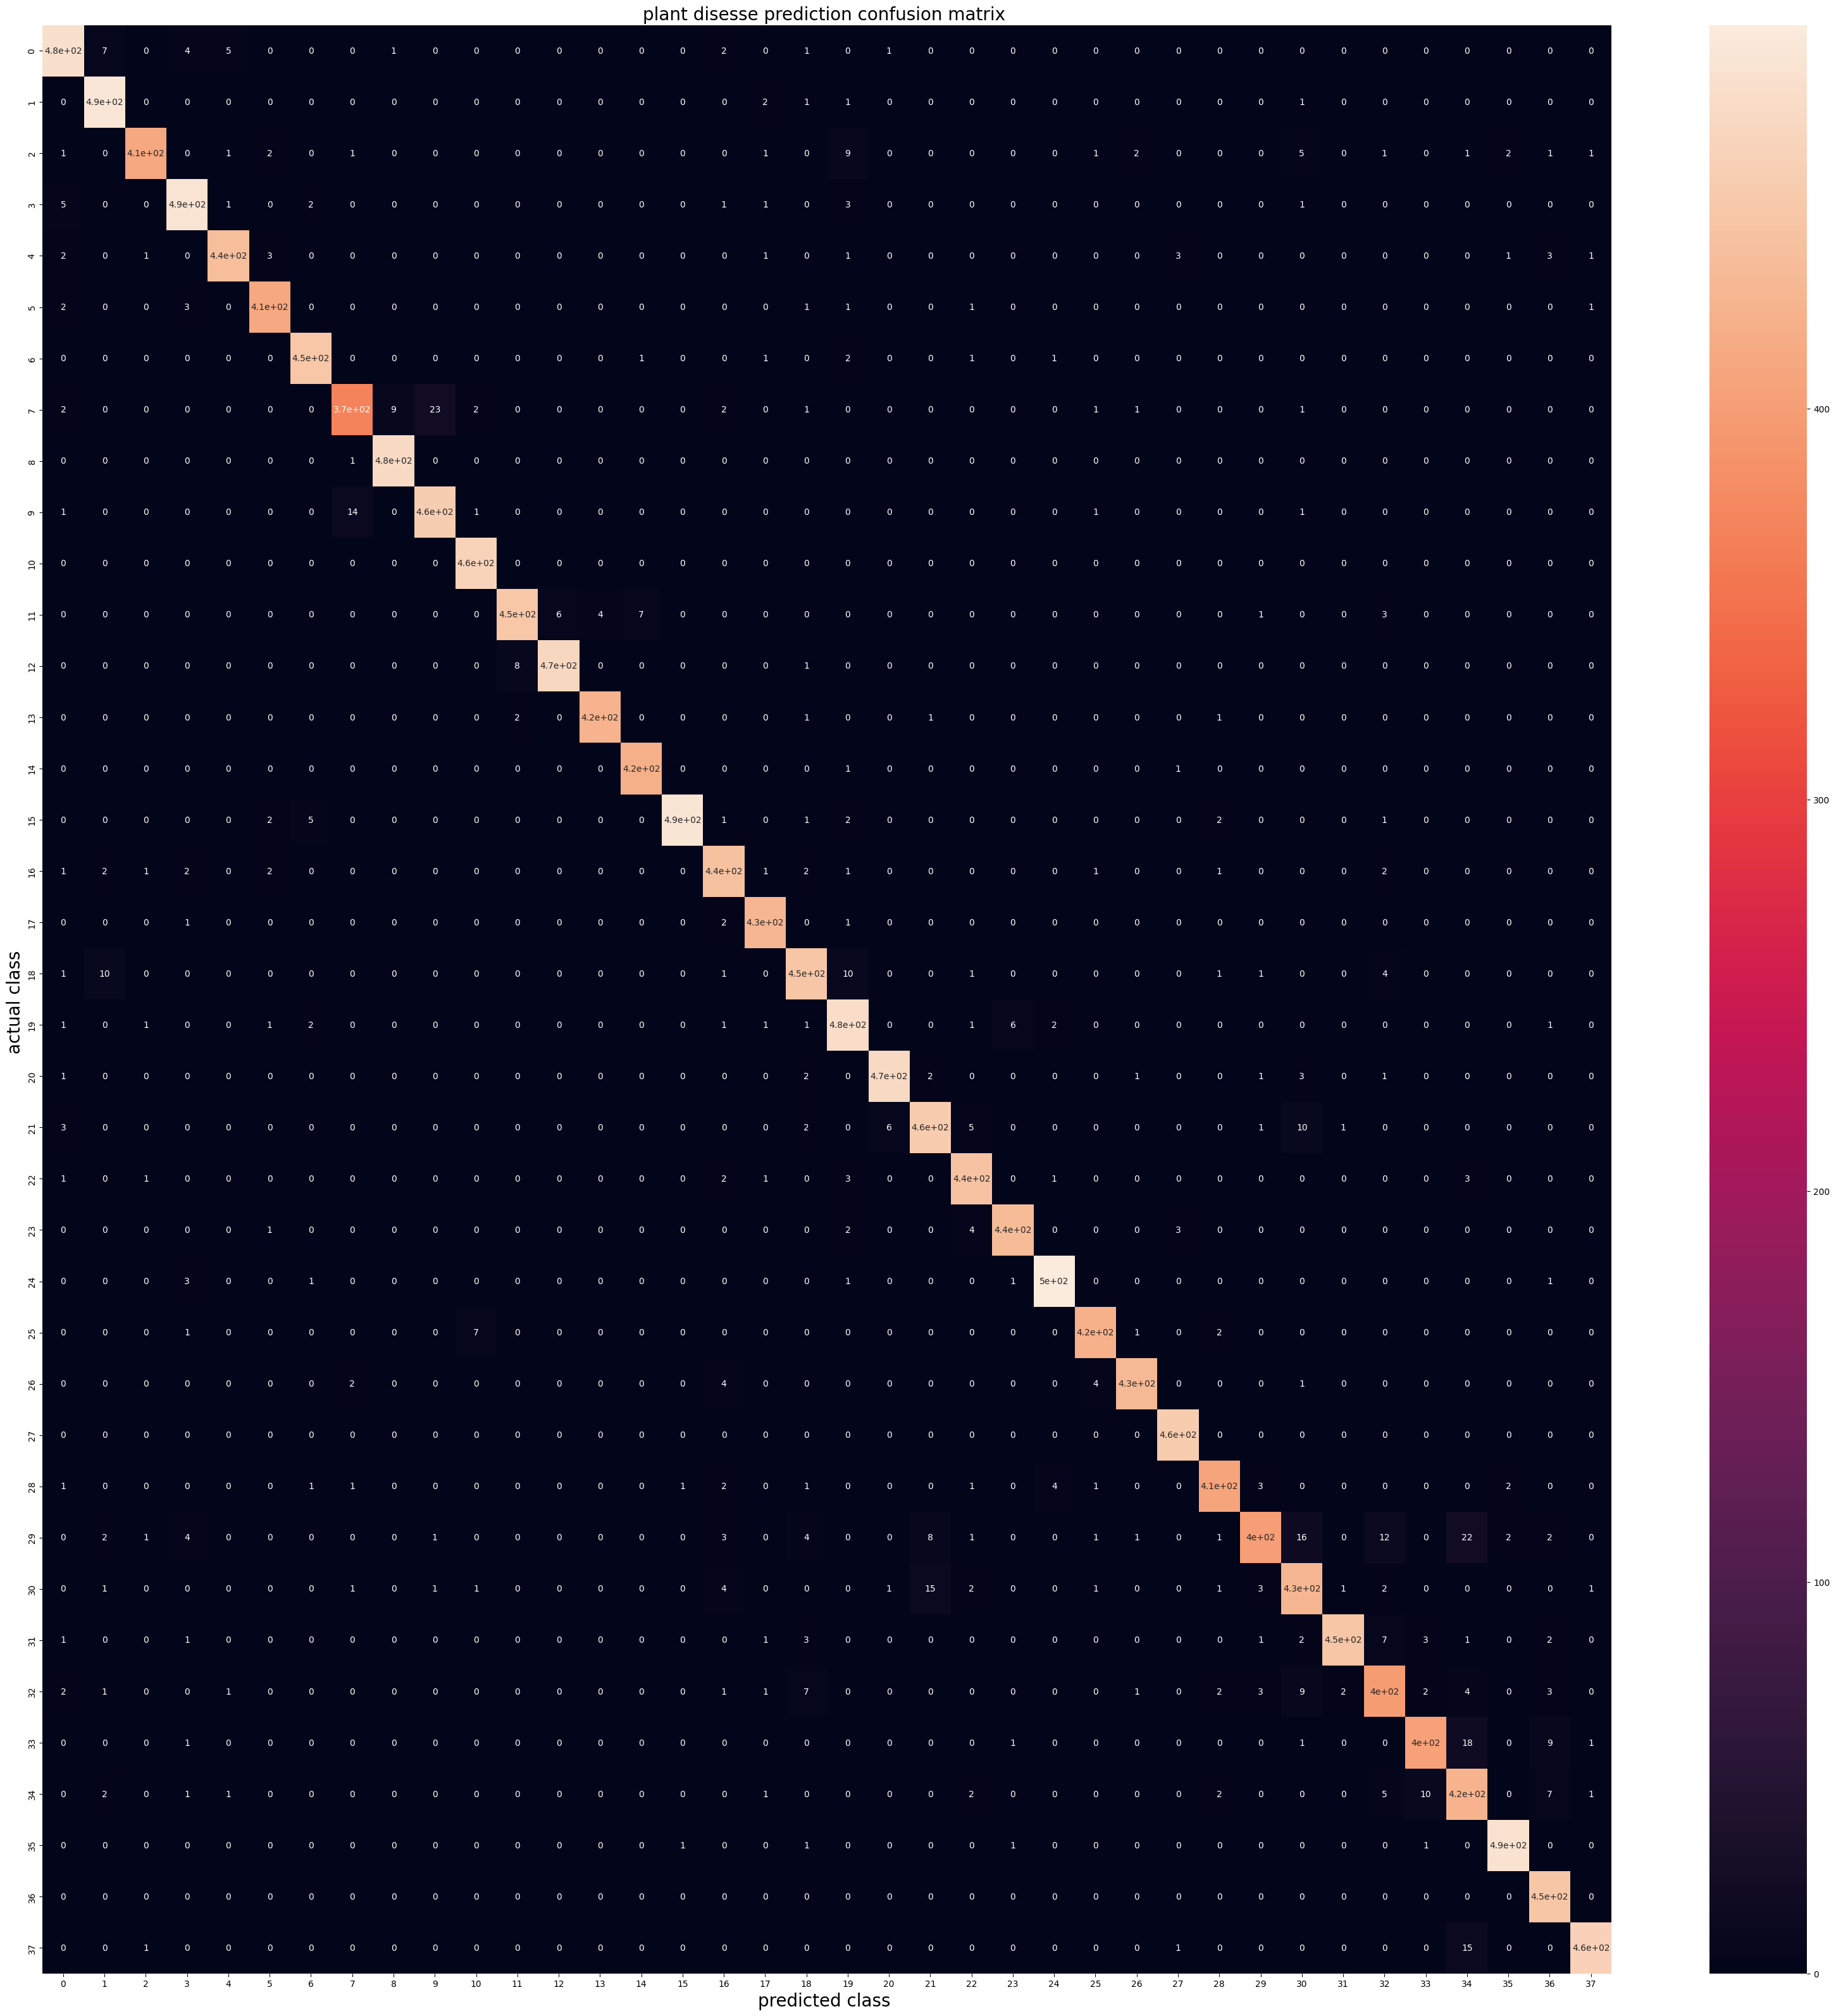

In [201]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("predicted class ", fontsize=20)
plt.ylabel("actual class ", fontsize=20)
plt.title("plant disesse prediction confusion matrix ", fontsize=20)
plt.show()